# NB10 — PLS: Vigor Feature Structure × Model Parameters

Two complementary analyses:

**Analysis 1 — PLS at subject level (N=293)**  
Find the low-dimensional shared structure between model parameters (z, κ, β)
and vigor features across trial phases (7 residualized features).  
Significance via permutation test (5,000 shuffles). Bootstrap 95% CI on loadings.

**Analysis 2 — Trial-level survival → vigor LMM (N≈13k choice trials)**  
Compute trial-specific survival probability S_i = exp(−T · D^{z_i}) from
fitted parameters and trial features. Regress phase vigor on S_i, testing
whether within-subject dynamic modulation follows the model prediction.
Test z_i × S_i interaction.

In [1]:
# =============================================================================
# Setup
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.cross_decomposition import PLSCanonical
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
DPI = 150

ROOT      = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
STATS_DIR  = ROOT / 'results' / 'stats'
TABLES_DIR = ROOT / 'results' / 'tables'
FIGS_DIR   = ROOT / 'figs'
TABLES_DIR.mkdir(parents=True, exist_ok=True)

import glob
stage5_dirs = sorted(glob.glob(str(ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage5_filtered_data_*')))
STAGE5_DIR = Path(stage5_dirs[-1])

# Vigor features to use (residualized stream — removes demand-curve variance)
VIGOR_FEATURES = [
    'onset_slope_resid',    # anticipatory: rate of ramp-up
    'onset_mean_resid',     # anticipatory: overall drive level
    'enc_pre_mean_resid',   # just before encounter: baseline
    'enc_post_mean_resid',  # just after encounter: reactive level
    'enc_spike_resid',      # post − pre: encounter-triggered increment
    'term_mean_resid',      # terminal: persistence magnitude
    'term_slope_resid',     # terminal: acceleration toward resolution
]

FEATURE_LABELS = [
    'Anticipatory\nslope', 'Anticipatory\nmean', 'Pre-enc\nbaseline',
    'Post-enc\nmean', 'Encounter\nspike', 'Terminal\nmean', 'Terminal\nslope'
]

PARAM_LABELS = ['z (hazard\nsensitivity)', 'κ (effort\ndiscounting)', 'β (threat\nbias)']

print('Setup complete.')

Setup complete.


## Analysis 1: PLS at Subject Level

In [2]:
# =============================================================================
# Load data and build subject-level matrices
# =============================================================================

# ── Load trial-level vigor features ──────────────────────────────────────────
pvm = pd.read_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet')
print(f'phase_vigor_metrics: {pvm.shape}')

# Subject-level mean vigor features (all trials, including probe trials)
Y_subj = (
    pvm.groupby('subj')[VIGOR_FEATURES]
    .mean()
    .reset_index()
)
print(f'Subject-level vigor: {Y_subj.shape}  (subjects × features)')

# ── Load model parameters ─────────────────────────────────────────────────────
z_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_z_params.csv').rename(
    columns={'subject': 'subj', 'mean': 'z'})[['subj', 'z']]
k_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_k_params.csv').rename(
    columns={'subject': 'subj', 'mean': 'kappa'})[['subj', 'kappa']]
b_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_beta_params.csv').rename(
    columns={'subject': 'subj', 'mean': 'beta'})[['subj', 'beta']]

params = z_df.merge(k_df, on='subj').merge(b_df, on='subj')
print(f'Parameters: {params.shape}')

# ── Merge and align ───────────────────────────────────────────────────────────
df = Y_subj.merge(params, on='subj').dropna()
print(f'Merged (after dropna): {df.shape}  ({df.shape[0]} subjects)')

# ── Build matrices ────────────────────────────────────────────────────────────
X_raw = df[['z', 'kappa', 'beta']].values          # N × 3
Y_raw = df[VIGOR_FEATURES].values                   # N × 7

# Z-score both sets independently
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X = scaler_X.fit_transform(X_raw)
Y = scaler_Y.fit_transform(Y_raw)

N, p = X.shape
_, q = Y.shape
print(f'\nX (params): {X.shape}, Y (vigor features): {Y.shape}')
print(f'Max PLS components: min({p}, {q}) = {min(p, q)}')

# Quick look at raw cross-covariance
print('\nCross-covariance matrix (params × vigor features):')
cc = pd.DataFrame(np.round((X.T @ Y) / N, 3),
                  index=['z', 'kappa', 'beta'],
                  columns=VIGOR_FEATURES)
print(cc.to_string())

phase_vigor_metrics: (23556, 33)
Subject-level vigor: (293, 8)  (subjects × features)
Parameters: (293, 4)
Merged (after dropna): (293, 11)  (293 subjects)

X (params): (293, 3), Y (vigor features): (293, 7)
Max PLS components: min(3, 7) = 3

Cross-covariance matrix (params × vigor features):
       onset_slope_resid  onset_mean_resid  enc_pre_mean_resid  enc_post_mean_resid  enc_spike_resid  term_mean_resid  term_slope_resid
z                  0.099             0.192               0.148                0.050           -0.126           -0.079            -0.192
kappa             -0.174            -0.095              -0.135               -0.167           -0.084           -0.224            -0.019
beta               0.130             0.046               0.036                0.095            0.106            0.028            -0.080


In [3]:
# =============================================================================
# Fit PLS and permutation test
# =============================================================================
N_PERM = 5000
N_BOOT = 5000
N_COMP = min(p, q)  # = 3

# ── Observed PLS ──────────────────────────────────────────────────────────────
pls = PLSCanonical(n_components=N_COMP, scale=False)
pls.fit(X, Y)

# Singular values (square root of explained cross-covariance)
# For PLSCanonical: x_weights_ and y_weights_ are the loading vectors
# x_loadings_ and y_loadings_ are the structure coefficients (correlations of
#   original variables with their canonical variate)
X_scores, Y_scores = pls.transform(X, Y)

# Singular values: covariance between X and Y scores per component
obs_cov = np.array([np.cov(X_scores[:, c], Y_scores[:, c])[0, 1]
                    for c in range(N_COMP)])
print('Observed X–Y score covariance per component:', np.round(obs_cov, 4))

# Correlation between X and Y canonical variates (canonical correlations)
obs_r = np.array([np.corrcoef(X_scores[:, c], Y_scores[:, c])[0, 1]
                  for c in range(N_COMP)])
print('Canonical correlations r:', np.round(obs_r, 4))

# ── Permutation test ──────────────────────────────────────────────────────────
print(f'\nRunning permutation test ({N_PERM} permutations)...')
perm_cov = np.zeros((N_PERM, N_COMP))

for i in range(N_PERM):
    X_perm = X[np.random.permutation(N)]
    pls_p = PLSCanonical(n_components=N_COMP, scale=False)
    pls_p.fit(X_perm, Y)
    Xs_p, Ys_p = pls_p.transform(X_perm, Y)
    perm_cov[i] = [np.cov(Xs_p[:, c], Ys_p[:, c])[0, 1]
                   for c in range(N_COMP)]

p_values = np.array([(perm_cov[:, c] >= obs_cov[c]).mean()
                      for c in range(N_COMP)])

print('\nPermutation p-values per component:')
for c in range(N_COMP):
    sig = '***' if p_values[c] < 0.001 else ('**' if p_values[c] < 0.01
          else ('*' if p_values[c] < 0.05 else 'n.s.'))
    print(f'  Component {c+1}: cov={obs_cov[c]:.4f}, r={obs_r[c]:.3f}, '
          f'p={p_values[c]:.4f} {sig}')

Observed X–Y score covariance per component: [0.4486 0.326  0.1168]
Canonical correlations r: [0.2537 0.2512 0.1251]

Running permutation test (5000 permutations)...

Permutation p-values per component:
  Component 1: cov=0.4486, r=0.254, p=0.0032 **
  Component 2: cov=0.3260, r=0.251, p=0.0000 ***
  Component 3: cov=0.1168, r=0.125, p=0.0048 **


In [4]:
# =============================================================================
# Bootstrap confidence intervals on loadings (with sign alignment)
# =============================================================================
# PLSCanonical has sign indeterminacy: each component's sign is arbitrary and
# can flip between bootstrap resamples. We fix this by aligning each bootstrap
# component's sign to the observed solution before storing loadings.
print(f'Running bootstrap ({N_BOOT} resamples, with sign alignment)...')

boot_x_struct = np.zeros((N_BOOT, p, N_COMP))
boot_y_struct = np.zeros((N_BOOT, q, N_COMP))

for i in range(N_BOOT):
    idx = np.random.choice(N, N, replace=True)
    pls_b = PLSCanonical(n_components=N_COMP, scale=False)
    pls_b.fit(X[idx], Y[idx])
    Xs_b, Ys_b = pls_b.transform(X[idx], Y[idx])

    # Align sign of each component to the observed solution
    # (compare bootstrap X-scores on resampled subjects to observed X-scores on same subjects)
    Xs_obs_i = X_scores[idx]
    for c in range(N_COMP):
        r = np.corrcoef(Xs_b[:, c], Xs_obs_i[:, c])[0, 1]
        sign = np.sign(r) if not np.isnan(r) and r != 0 else 1.0
        boot_x_struct[i, :, c] = sign * np.array([
            np.corrcoef(X[idx, j], Xs_b[:, c])[0, 1] for j in range(p)
        ])
        boot_y_struct[i, :, c] = sign * np.array([
            np.corrcoef(Y[idx, j], Ys_b[:, c])[0, 1] for j in range(q)
        ])

# Observed structure coefficients (correlation of original vars with canonical variates)
obs_x_struct = np.array([[np.corrcoef(X[:, j], X_scores[:, c])[0, 1]
                           for j in range(p)] for c in range(N_COMP)]).T  # p × N_COMP
obs_y_struct = np.array([[np.corrcoef(Y[:, j], Y_scores[:, c])[0, 1]
                           for j in range(q)] for c in range(N_COMP)]).T  # q × N_COMP

# 95% CI
x_ci_lo = np.percentile(boot_x_struct, 2.5, axis=0)
x_ci_hi = np.percentile(boot_x_struct, 97.5, axis=0)
y_ci_lo = np.percentile(boot_y_struct, 2.5, axis=0)
y_ci_hi = np.percentile(boot_y_struct, 97.5, axis=0)

print('\nX structure coefficients (params → component) with 95% CI:')
for c in range(N_COMP):
    print(f'  Component {c+1} (r={obs_r[c]:.3f}, perm p={p_values[c]:.4f}):')
    for j, name in enumerate(['z', 'kappa', 'beta']):
        ci_lo, ci_hi = x_ci_lo[j, c], x_ci_hi[j, c]
        sig = ' *' if not (ci_lo <= 0 <= ci_hi) else ''
        print(f'    {name}: {obs_x_struct[j,c]:+.3f} [{ci_lo:+.3f}, {ci_hi:+.3f}]{sig}')

print('\nY structure coefficients (vigor features → component) with 95% CI:')
for c in range(N_COMP):
    print(f'  Component {c+1}:')
    for j, name in enumerate(VIGOR_FEATURES):
        ci_lo, ci_hi = y_ci_lo[j, c], y_ci_hi[j, c]
        sig = ' *' if not (ci_lo <= 0 <= ci_hi) else ''
        print(f'    {name}: {obs_y_struct[j,c]:+.3f} [{ci_lo:+.3f}, {ci_hi:+.3f}]{sig}')

Running bootstrap (5000 resamples, with sign alignment)...

X structure coefficients (params → component) with 95% CI:
  Component 1 (r=0.254, perm p=0.0032):
    z: -0.463 [-0.986, +0.634]
    kappa: +0.662 [-0.433, +0.991]
    beta: -0.379 [-0.868, +0.316]
  Component 2 (r=0.251, perm p=0.0000):
    z: +0.875 [-0.116, +0.992]
    kappa: +0.627 [-0.425, +0.970]
    beta: +0.015 [-0.793, +0.700]
  Component 3 (r=0.125, perm p=0.0048):
    z: -0.142 [-0.736, +0.495]
    kappa: +0.411 [-0.201, +0.942]
    beta: +0.925 [+0.227, +0.997] *

Y structure coefficients (vigor features → component) with 95% CI:
  Component 1:
    onset_slope_resid: -0.883 [-0.922, -0.366] *
    onset_mean_resid: -0.782 [-0.936, -0.150] *
    enc_pre_mean_resid: -0.919 [-0.964, -0.378] *
    enc_post_mean_resid: -0.929 [-0.985, -0.250] *
    enc_spike_resid: -0.236 [-0.752, +0.545]
    term_mean_resid: -0.678 [-0.901, +0.062]
    term_slope_resid: +0.586 [+0.075, +0.771] *
  Component 2:
    onset_slope_resid: -0

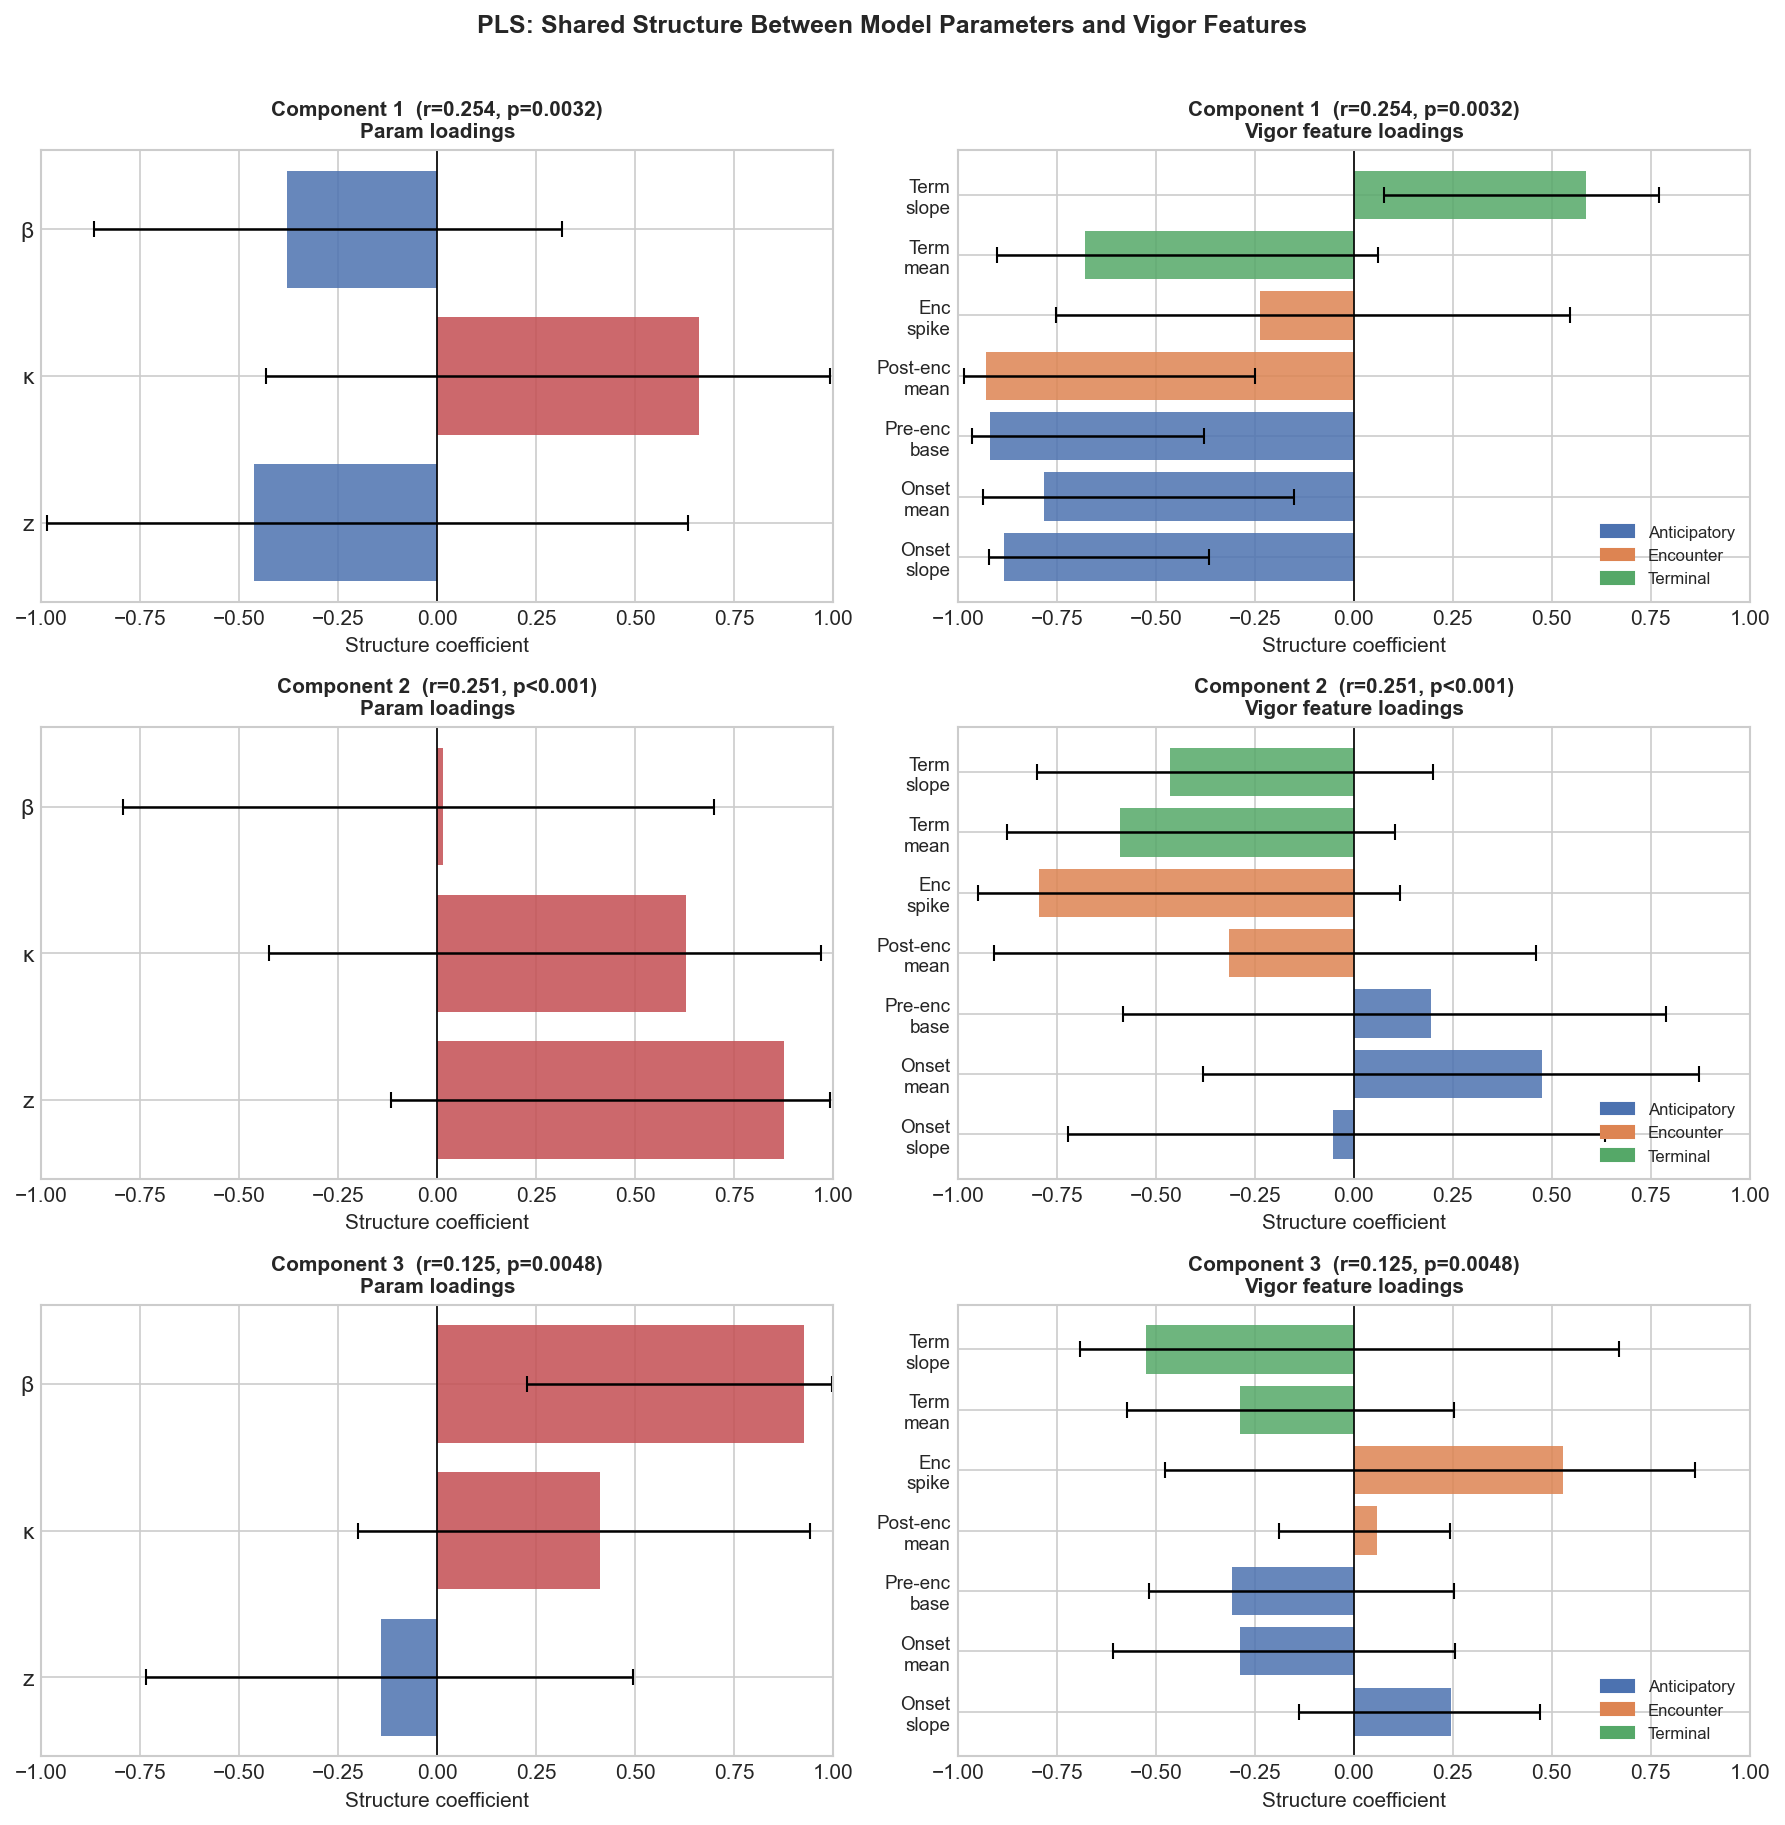

Saved fig_pls_vigor_params.png


In [5]:
# =============================================================================
# Figure: PLS loading plots (one panel per significant component)
# =============================================================================
sig_comps = [c for c in range(N_COMP) if p_values[c] < 0.05]
n_sig = max(len(sig_comps), 1)  # at least show component 1 even if n.s.
if not sig_comps:
    sig_comps = [0]

fig, axes = plt.subplots(n_sig, 2, figsize=(12, 4 * n_sig), dpi=DPI)
if n_sig == 1:
    axes = axes[np.newaxis, :]

PARAM_SHORT = ['z', 'κ', 'β']
VIGOR_SHORT = ['Onset\nslope', 'Onset\nmean', 'Pre-enc\nbase', 'Post-enc\nmean',
               'Enc\nspike', 'Term\nmean', 'Term\nslope']

# Color: anticipatory phase (blue), encounter phase (orange), terminal phase (green)
PHASE_COLORS = ['#4c72b0'] * 3 + ['#dd8452'] * 2 + ['#55a868'] * 2

for i, c in enumerate(sig_comps):
    p_str = f'p={p_values[c]:.4f}' if p_values[c] >= 0.001 else 'p<0.001'
    comp_label = f'Component {c+1}  (r={obs_r[c]:.3f}, {p_str})'

    # Left panel: param structure coefficients
    ax_x = axes[i, 0]
    x_vals = obs_x_struct[:, c]
    x_err_lo = x_vals - x_ci_lo[:, c]
    x_err_hi = x_ci_hi[:, c] - x_vals
    colors_x = ['#c44e52' if v > 0 else '#4c72b0' for v in x_vals]
    bars = ax_x.barh(range(p), x_vals, xerr=[x_err_lo, x_err_hi],
                     color=colors_x, alpha=0.85, capsize=4, error_kw={'elinewidth': 1.2})
    ax_x.axvline(0, color='black', linewidth=0.8)
    ax_x.set_yticks(range(p))
    ax_x.set_yticklabels(PARAM_SHORT, fontsize=11)
    ax_x.set_xlabel('Structure coefficient', fontsize=10)
    ax_x.set_title(f'{comp_label}\nParam loadings', fontsize=10, fontweight='bold')
    ax_x.set_xlim(-1, 1)

    # Right panel: vigor feature structure coefficients
    ax_y = axes[i, 1]
    y_vals = obs_y_struct[:, c]
    y_err_lo = y_vals - y_ci_lo[:, c]
    y_err_hi = y_ci_hi[:, c] - y_vals
    ax_y.barh(range(q), y_vals, xerr=[y_err_lo, y_err_hi],
              color=PHASE_COLORS, alpha=0.85, capsize=4,
              error_kw={'elinewidth': 1.2})
    ax_y.axvline(0, color='black', linewidth=0.8)
    ax_y.set_yticks(range(q))
    ax_y.set_yticklabels(VIGOR_SHORT, fontsize=9)
    ax_y.set_xlabel('Structure coefficient', fontsize=10)
    ax_y.set_title(f'{comp_label}\nVigor feature loadings', fontsize=10, fontweight='bold')
    ax_y.set_xlim(-1, 1)

    # Phase legend
    legend_patches = [
        mpatches.Patch(color='#4c72b0', label='Anticipatory'),
        mpatches.Patch(color='#dd8452', label='Encounter'),
        mpatches.Patch(color='#55a868', label='Terminal'),
    ]
    ax_y.legend(handles=legend_patches, fontsize=8, loc='lower right')

plt.suptitle('PLS: Shared Structure Between Model Parameters and Vigor Features',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig_pls_vigor_params.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig_pls_vigor_params.png')

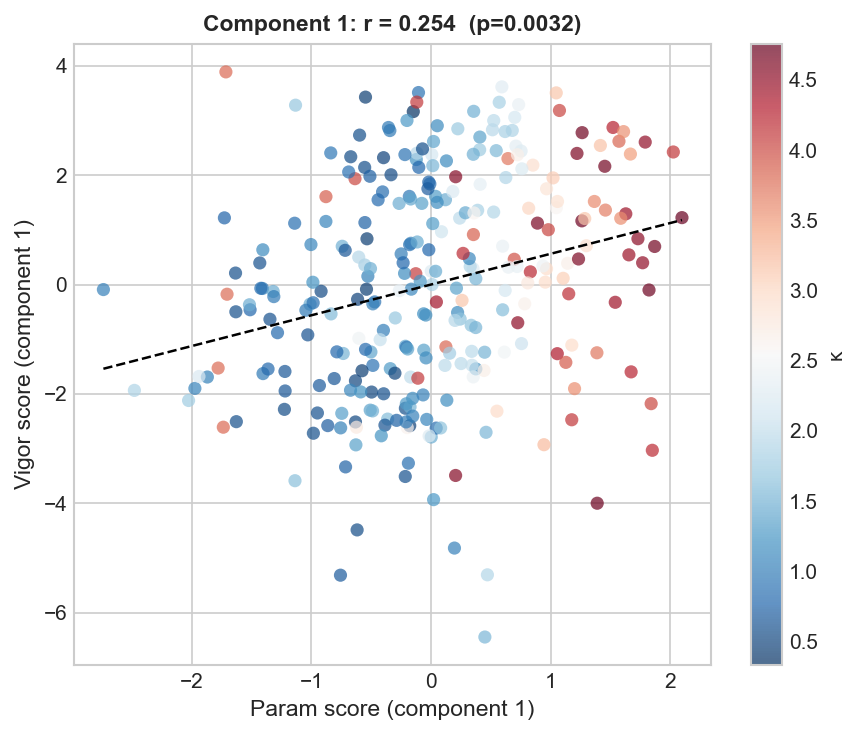

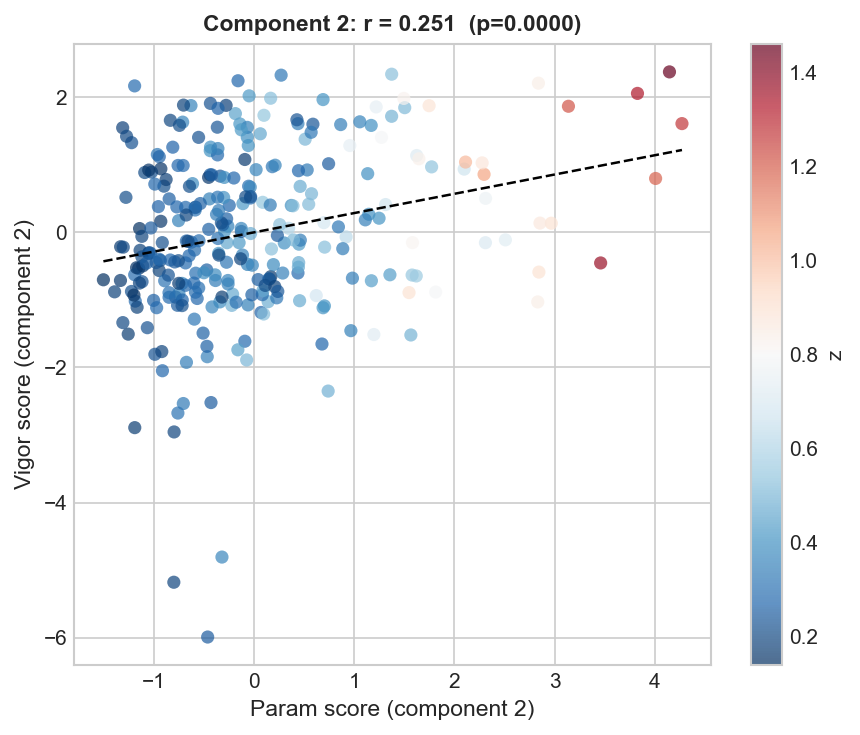

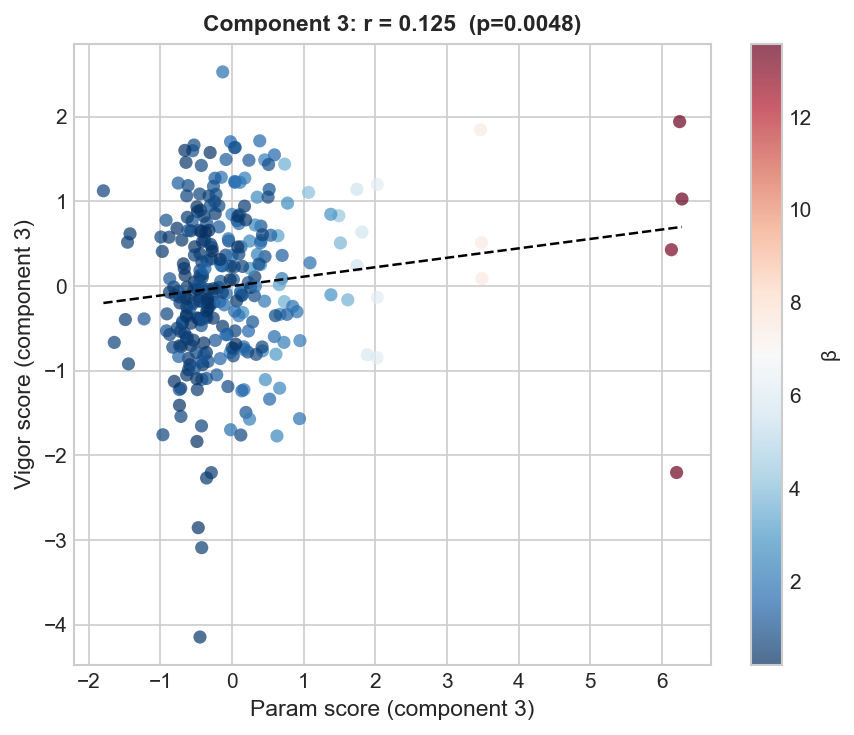

Score scatter plots saved.


In [6]:
# =============================================================================
# Component score scatter (X score vs Y score, coloured by dominant param)
# =============================================================================
for c in sig_comps:
    fig, ax = plt.subplots(figsize=(6, 5), dpi=DPI)
    # Colour by the param with the largest absolute structure coefficient on this component
    dominant_param = np.argmax(np.abs(obs_x_struct[:, c]))
    param_vals = X_raw[:, dominant_param]
    sc = ax.scatter(X_scores[:, c], Y_scores[:, c],
                    c=param_vals, cmap='RdBu_r', alpha=0.7, s=40, edgecolors='none')
    plt.colorbar(sc, ax=ax, label=PARAM_SHORT[dominant_param])
    r = obs_r[c]
    ax.set_xlabel(f'Param score (component {c+1})', fontsize=11)
    ax.set_ylabel(f'Vigor score (component {c+1})', fontsize=11)
    ax.set_title(f'Component {c+1}: r = {r:.3f}  (p={p_values[c]:.4f})',
                 fontsize=11, fontweight='bold')

    # Regression line
    m, b_int = np.polyfit(X_scores[:, c], Y_scores[:, c], 1)
    xr = np.linspace(X_scores[:, c].min(), X_scores[:, c].max(), 100)
    ax.plot(xr, m * xr + b_int, 'k--', linewidth=1.2)

    plt.tight_layout()
    fig.savefig(FIGS_DIR / f'fig_pls_scores_c{c+1}.png', dpi=DPI, bbox_inches='tight')
    plt.show()

print('Score scatter plots saved.')

In [7]:
# =============================================================================
# Save PLS results table
# =============================================================================
rows = []
for c in range(N_COMP):
    for j, pname in enumerate(['z', 'kappa', 'beta']):
        rows.append({
            'component': c + 1,
            'variable_set': 'param',
            'variable': pname,
            'structure_coef': obs_x_struct[j, c],
            'ci_lo': x_ci_lo[j, c],
            'ci_hi': x_ci_hi[j, c],
            'perm_p': p_values[c],
            'canonical_r': obs_r[c],
        })
    for j, vname in enumerate(VIGOR_FEATURES):
        rows.append({
            'component': c + 1,
            'variable_set': 'vigor',
            'variable': vname,
            'structure_coef': obs_y_struct[j, c],
            'ci_lo': y_ci_lo[j, c],
            'ci_hi': y_ci_hi[j, c],
            'perm_p': p_values[c],
            'canonical_r': obs_r[c],
        })

pls_table = pd.DataFrame(rows)
pls_table.to_csv(TABLES_DIR / 'pls_vigor_params.csv', index=False)
print('Saved pls_vigor_params.csv')
print(pls_table.groupby(['component', 'variable_set'])[['variable', 'structure_coef', 'ci_lo', 'ci_hi']].apply(lambda x: x).to_string())

Saved pls_vigor_params.csv
                                      variable  structure_coef     ci_lo     ci_hi
component variable_set                                                            
1         param        0                     z       -0.462660 -0.986232  0.633739
                       1                 kappa        0.661626 -0.433256  0.991367
                       2                  beta       -0.379093 -0.868354  0.315552
          vigor        3     onset_slope_resid       -0.882917 -0.921746 -0.366010
                       4      onset_mean_resid       -0.781583 -0.935624 -0.150010
                       5    enc_pre_mean_resid       -0.919372 -0.963740 -0.377807
                       6   enc_post_mean_resid       -0.929157 -0.984549 -0.249747
                       7       enc_spike_resid       -0.235678 -0.752352  0.545071
                       8       term_mean_resid       -0.678343 -0.900968  0.061946
                       9      term_slope_resid        0.5860

## Analysis 2: Trial-Level Survival → Vigor LMM

Compute trial-specific survival probability S_i = exp(−T_i · D_chosen^{z_i})
using each participant's fitted z_i and the trial's threat level T_i and
chosen option distance D_chosen_i.

Regress each phase vigor measure on S_i to test whether within-subject
trial-to-trial variation in computed survival predicts vigor modulation.
Test z_i × S_i interaction.

In [8]:
# =============================================================================
# Compute trial-level survival probability
# =============================================================================

# ── Load choice trials (behavior.csv — 45 trials/subj, no probe trials) ──────
beh = pd.read_csv(STAGE5_DIR / 'behavior.csv')
print(f'behavior.csv: {beh.shape}  ({beh.subj.nunique()} subjects, '
      f'{len(beh)/beh.subj.nunique():.0f} trials/subj)')

# Chosen option distance: low option always distance_L=1; high option = distance_H
beh['D_chosen'] = np.where(beh['choice'] == 0, beh['distance_L'], beh['distance_H'])

# Merge subject-level params
beh = beh.merge(z_df.rename(columns={'z': 'z_i'}), on='subj', how='left')
beh = beh.merge(k_df.rename(columns={'kappa': 'kappa_i'}), on='subj', how='left')

# Survival probability: S_i = exp(-threat * D_chosen^z_i)
beh['S_trial'] = np.exp(-beh['threat'] * beh['D_chosen'] ** beh['z_i'])

# Standardize
beh['S_trial_z'] = (beh['S_trial'] - beh['S_trial'].mean()) / beh['S_trial'].std()
beh['z_i_z']     = (beh['z_i']    - beh['z_i'].mean())    / beh['z_i'].std()
beh['kappa_i_z'] = (beh['kappa_i'] - beh['kappa_i'].mean()) / beh['kappa_i'].std()

print(f'S_trial range: [{beh.S_trial.min():.3f}, {beh.S_trial.max():.3f}]')
print(f'S_trial mean:  {beh.S_trial.mean():.3f}  SD: {beh.S_trial.std():.3f}')
print(beh[['subj','trial','threat','D_chosen','z_i','S_trial']].head(6))

# ── Merge onto pvm (only bring in columns pvm doesn't already have) ───────────
# pvm already has: threat, threat_c, choice, outcome, etc.
beh_extra = beh[['subj', 'trial', 'S_trial_z', 'S_trial', 'z_i_z', 'kappa_i_z', 'D_chosen']]
pvm_choice = pvm.merge(beh_extra, on=['subj', 'trial'], how='inner')

# dist_c: center D_chosen after merge
pvm_choice['dist_c'] = pvm_choice['D_chosen'] - pvm_choice['D_chosen'].mean()

print(f'\nMerged choice trials with vigor: {pvm_choice.shape}')
print(f'Subjects: {pvm_choice.subj.nunique()}, Trials: {pvm_choice.trial.nunique()}')
print(f'Columns: {pvm_choice.columns.tolist()}')

behavior.csv: (13185, 10)  (293 subjects, 45 trials/subj)
S_trial range: [0.225, 0.905]
S_trial mean:  0.629  SD: 0.203
   subj  trial  threat  D_chosen      z_i   S_trial
0     1      1     0.1         1  0.41823  0.904837
1     1      2     0.9         1  0.41823  0.406570
2     1      3     0.5         1  0.41823  0.606531
3     1      4     0.9         1  0.41823  0.406570
4     1      5     0.1         1  0.41823  0.904837
5     1      6     0.1         1  0.41823  0.904837

Merged choice trials with vigor: (13101, 39)
Subjects: 293, Trials: 45
Columns: ['subj', 'trial', 'participantID', 'trialName', 'threat', 'choice', 'outcome', 'isAttackTrial', 'encounterTime', 'trialEscapeTime', 'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H', 'resolution_time', 'attack', 'threat_c', 'escaped', 'onset_slope_resid', 'onset_mean_resid', 'enc_pre_mean_resid', 'enc_post_mean_resid', 'enc_spike_resid', 'term_mean_resid', 'term_slope_resid', 'onset_slope_norm', 'onset_m

In [9]:
# =============================================================================
# LMM: vigor_phase ~ S_trial_z + threat_c + choice + dist_c + (1|subj)
# Plus z_i × S_trial_z interaction
# =============================================================================
VIGOR_DVS = [
    ('onset_slope_resid',  'Anticipatory slope'),
    ('onset_mean_resid',   'Anticipatory mean'),
    ('enc_spike_resid',    'Encounter spike'),
    ('enc_post_mean_resid','Post-encounter mean'),
    ('term_mean_resid',    'Terminal mean'),
]

results = []

for dv, label in VIGOR_DVS:
    subset = pvm_choice[['subj', dv, 'S_trial_z', 'threat_c', 'choice',
                          'dist_c', 'z_i_z', 'kappa_i_z']].dropna()
    subset = subset.reset_index(drop=True)

    # Model 1: main effect of S_trial
    try:
        m1 = smf.mixedlm(
            f'{dv} ~ S_trial_z + threat_c + C(choice) + dist_c',
            data=subset, groups=subset['subj']
        ).fit(reml=False, method='bfgs')

        beta_S = m1.params['S_trial_z']
        se_S   = m1.bse['S_trial_z']
        p_S    = m1.pvalues['S_trial_z']

        results.append({
            'DV': label, 'predictor': 'S_trial_z',
            'beta': beta_S, 'SE': se_S, 'p': p_S,
            'N_obs': len(subset), 'N_subj': subset.subj.nunique()
        })

        print(f'{label}: β(S)={beta_S:.4f}, SE={se_S:.4f}, p={p_S:.4e}')
    except Exception as e:
        print(f'{label}: FAILED — {e}')

    # Model 2: z_i × S_trial interaction
    try:
        m2 = smf.mixedlm(
            f'{dv} ~ S_trial_z * z_i_z + threat_c + C(choice) + dist_c',
            data=subset, groups=subset['subj']
        ).fit(reml=False, method='bfgs')

        beta_ix = m2.params['S_trial_z:z_i_z']
        se_ix   = m2.bse['S_trial_z:z_i_z']
        p_ix    = m2.pvalues['S_trial_z:z_i_z']

        results.append({
            'DV': label, 'predictor': 'S_trial_z × z_i_z',
            'beta': beta_ix, 'SE': se_ix, 'p': p_ix,
            'N_obs': len(subset), 'N_subj': subset.subj.nunique()
        })

        print(f'  z×S interaction: β={beta_ix:.4f}, SE={se_ix:.4f}, p={p_ix:.4e}')
    except Exception as e:
        print(f'  z×S interaction: FAILED — {e}')

# FDR correction across all tests
from statsmodels.stats.multitest import multipletests
res_df = pd.DataFrame(results)
_, res_df['p_fdr'], _, _ = multipletests(res_df['p'], method='fdr_bh')

print('\n=== Summary (FDR corrected) ===')
print(res_df[['DV','predictor','beta','SE','p','p_fdr']].to_string(index=False))

Anticipatory slope: β(S)=0.0009, SE=0.0021, p=6.6499e-01
  z×S interaction: β=0.0014, SE=0.0020, p=4.7571e-01
Anticipatory mean: β(S)=0.0002, SE=0.0014, p=8.6601e-01
  z×S interaction: β=0.0010, SE=0.0014, p=4.4688e-01
Encounter spike: β(S)=-0.0015, SE=0.0037, p=6.8619e-01
  z×S interaction: β=-0.0024, SE=0.0035, p=4.9142e-01
Post-encounter mean: β(S)=0.0057, SE=0.0035, p=1.0727e-01
  z×S interaction: β=0.0031, SE=0.0033, p=3.4179e-01
Terminal mean: β(S)=-0.0111, SE=0.0026, p=2.2510e-05
  z×S interaction: β=0.0039, SE=0.0025, p=1.2353e-01

=== Summary (FDR corrected) ===
                 DV         predictor      beta       SE        p    p_fdr
 Anticipatory slope         S_trial_z  0.000902 0.002083 0.664988 0.762434
 Anticipatory slope S_trial_z × z_i_z  0.001439 0.002018 0.475715 0.702025
  Anticipatory mean         S_trial_z  0.000240 0.001425 0.866012 0.866012
  Anticipatory mean S_trial_z × z_i_z  0.001050 0.001380 0.446876 0.702025
    Encounter spike         S_trial_z -0.001510

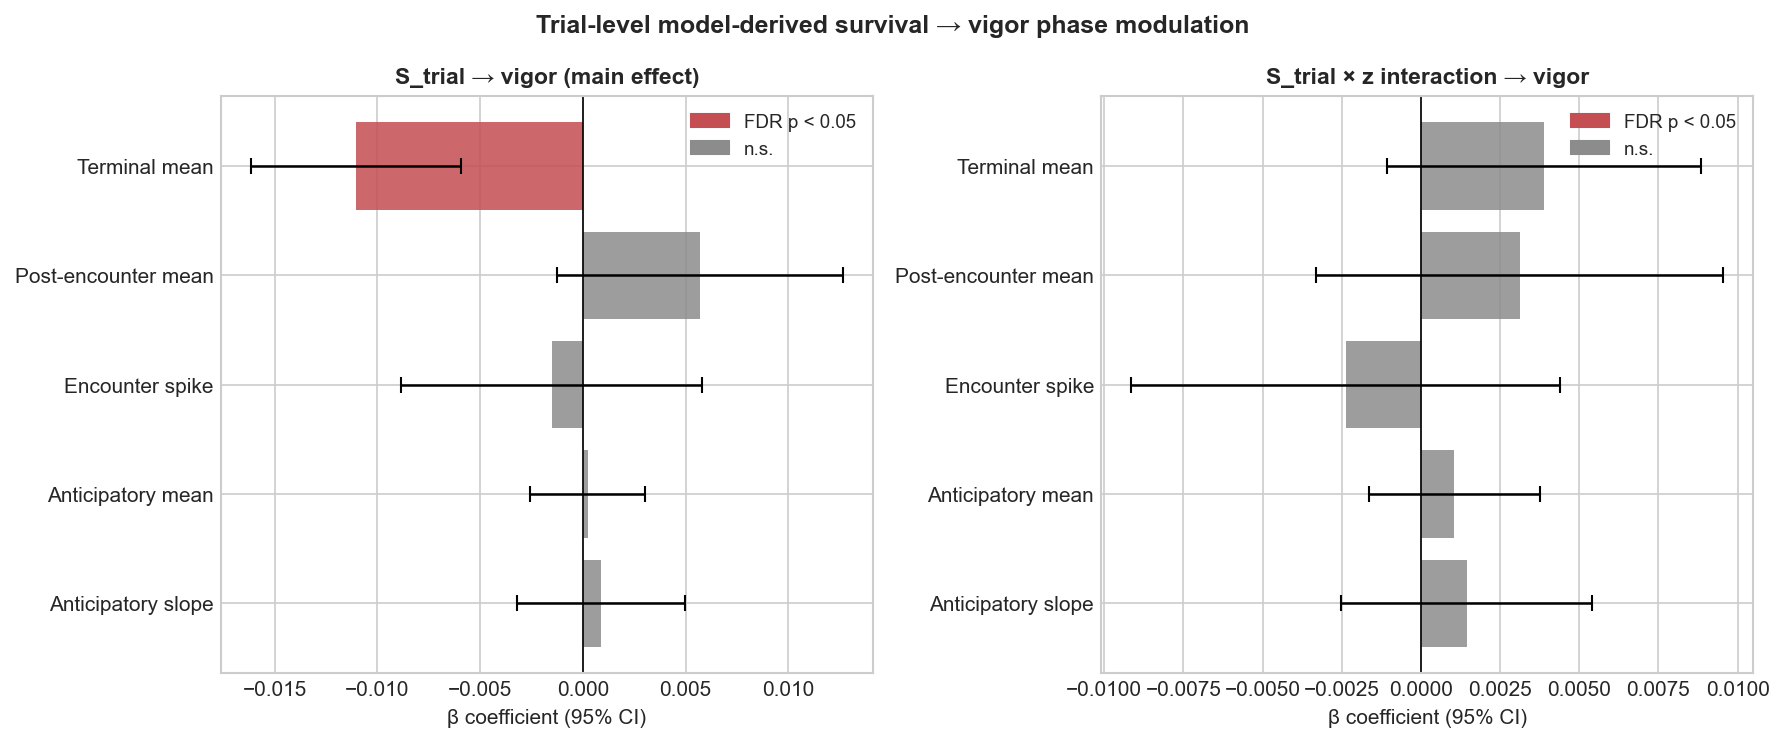

Saved fig_survival_vigor_lmm.png
Saved survival_vigor_lmm.csv


In [10]:
# =============================================================================
# Figure: S_trial → vigor across phases (forest plot)
# =============================================================================
S_results = res_df[res_df['predictor'] == 'S_trial_z'].copy().reset_index(drop=True)
ix_results = res_df[res_df['predictor'] == 'S_trial_z × z_i_z'].copy().reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

for ax, data, title in [
    (axes[0], S_results, 'S_trial → vigor (main effect)'),
    (axes[1], ix_results, 'S_trial × z interaction → vigor'),
]:
    y = range(len(data))
    colors = ['#c44e52' if p < 0.05 else '#8c8c8c' for p in data['p_fdr']]

    ax.barh(y, data['beta'], xerr=1.96 * data['SE'],
            color=colors, alpha=0.85, capsize=4,
            error_kw={'elinewidth': 1.2})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(data['DV'], fontsize=10)
    ax.set_xlabel('β coefficient (95% CI)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

    red_patch = mpatches.Patch(color='#c44e52', label='FDR p < 0.05')
    gray_patch = mpatches.Patch(color='#8c8c8c', label='n.s.')
    ax.legend(handles=[red_patch, gray_patch], fontsize=9)

plt.suptitle('Trial-level model-derived survival → vigor phase modulation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig_survival_vigor_lmm.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig_survival_vigor_lmm.png')

# Save table
res_df.to_csv(TABLES_DIR / 'survival_vigor_lmm.csv', index=False)
print('Saved survival_vigor_lmm.csv')

## Summary

**Analysis 1 — PLS:**  
See permutation p-values above for significant components. Structure coefficients
with 95% bootstrap CI identify which params and vigor features drive each shared
latent dimension. Components with reactive spike and terminal persistence near
zero (CI includes zero) indicate those phases are not part of the deliberative
system captured by choice parameters.

**Analysis 2 — Trial-level LMM:**  
Tests whether within-subject, trial-to-trial variation in model-derived survival
probability predicts vigor phase modulation. The z_i × S_trial interaction tests
whether subjects with higher hazard sensitivity show stronger coupling between
computed survival and executed vigor.